<a href="https://colab.research.google.com/github/AnikKushwaha/AnikKushwaha/blob/master/Jobwork2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

print("Total:", total_size)
print("Train:", train_size)
print("Val:", val_size)
print("Test:", test_size)

train_dataset, val_dataset, _ = random_split(full_dataset, [train_size, val_size, test_size])

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(" Data loading completed successfully!")


100%|██████████| 170M/170M [00:02<00:00, 73.6MB/s]


Total: 50000
Train: 35000
Val: 7500
Test: 7500
 Data loading completed successfully!


In [4]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
print("Model Ready")


Model Ready


In [7]:
num_epochs = 10
best_val_loss = np.inf
patience = 5
wait = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

print("Training Finished ")


Epoch [1/10] - Train Loss: 0.7897 | Val Loss: 0.7121 | Val Acc: 0.7540
Epoch [2/10] - Train Loss: 0.7675 | Val Loss: 0.7619 | Val Acc: 0.7303
Epoch [3/10] - Train Loss: 0.7493 | Val Loss: 0.6667 | Val Acc: 0.7652
Epoch [4/10] - Train Loss: 0.7337 | Val Loss: 0.6464 | Val Acc: 0.7725
Epoch [5/10] - Train Loss: 0.7162 | Val Loss: 0.6485 | Val Acc: 0.7684
Epoch [6/10] - Train Loss: 0.6960 | Val Loss: 0.6414 | Val Acc: 0.7781
Epoch [7/10] - Train Loss: 0.6874 | Val Loss: 0.6264 | Val Acc: 0.7812
Epoch [8/10] - Train Loss: 0.6713 | Val Loss: 0.6582 | Val Acc: 0.7689
Epoch [9/10] - Train Loss: 0.6547 | Val Loss: 0.6646 | Val Acc: 0.7729
Epoch [10/10] - Train Loss: 0.6398 | Val Loss: 0.6451 | Val Acc: 0.7809
Training Finished 


Test Loss: 0.6247 | Test Accuracy: 0.7860


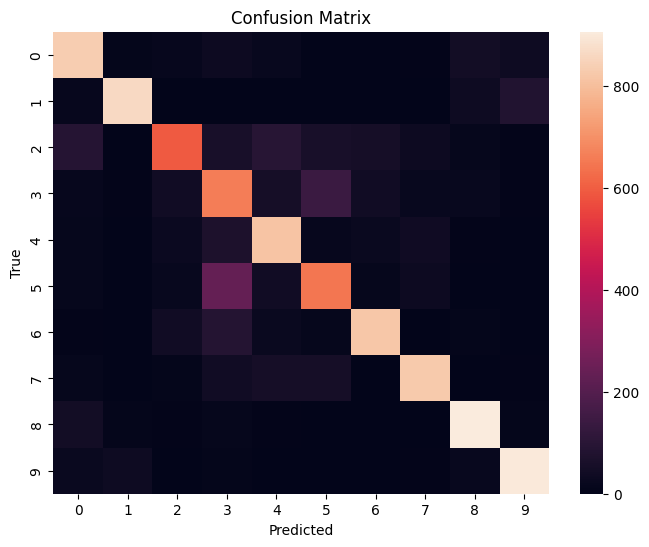

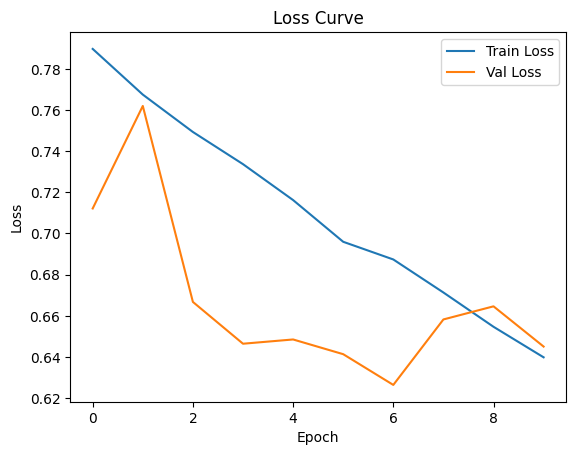

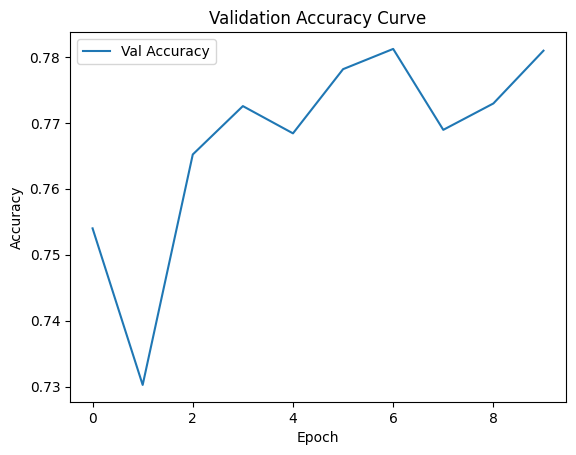

In [8]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_loss = 0
correct = 0
total = 0
predictions = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        predictions.extend(predicted.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_accuracy = correct / total
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")

cm = confusion_matrix(labels_list, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Curve")
plt.legend()
plt.show()


In [11]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

labels_np = np.array(labels_list)
pred_np = np.array(predictions)

precision = precision_score(labels_np, pred_np, average='weighted')
recall = recall_score(labels_np, pred_np, average='weighted')
f1 = f1_score(labels_np, pred_np, average='weighted')

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

classes = test_dataset.classes
print("\nClassification Report:")
print(classification_report(labels_np, pred_np, target_names=classes))



Precision: 0.7917
Recall: 0.7860
F1-Score: 0.7864

Classification Report:
              precision    recall  f1-score   support

    airplane       0.78      0.83      0.81      1000
  automobile       0.93      0.86      0.89      1000
        bird       0.79      0.59      0.68      1000
         cat       0.55      0.66      0.60      1000
        deer       0.74      0.81      0.77      1000
         dog       0.69      0.65      0.67      1000
        frog       0.85      0.82      0.84      1000
       horse       0.86      0.83      0.84      1000
        ship       0.86      0.91      0.88      1000
       truck       0.86      0.90      0.88      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



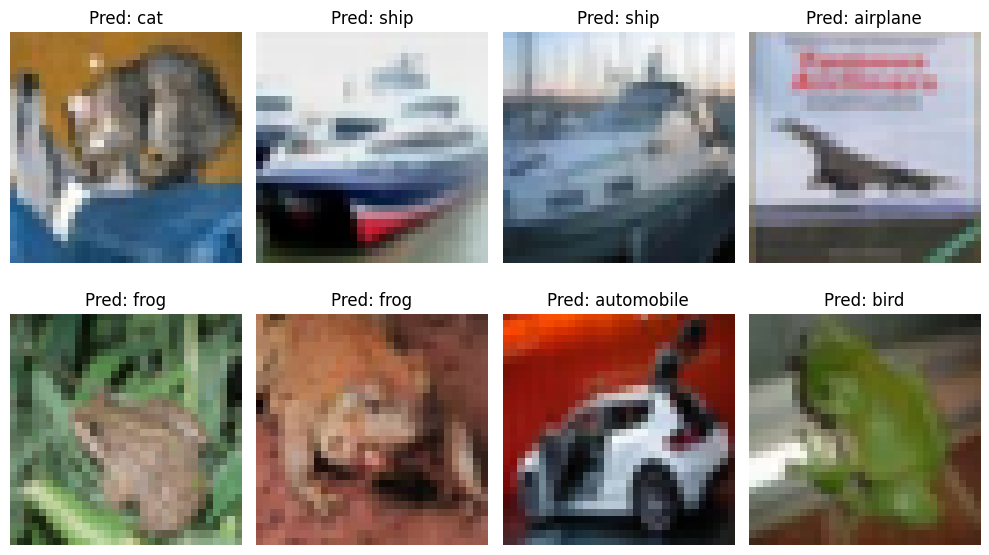

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

fig = plt.figure(figsize=(10, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = (img * 0.5) + 0.5
    plt.imshow(img)
    ax.set_title(f"Pred: {test_dataset.classes[preds[i]]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


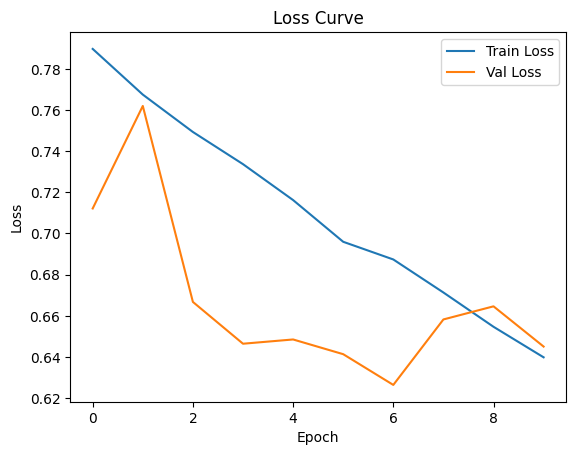

In [13]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()


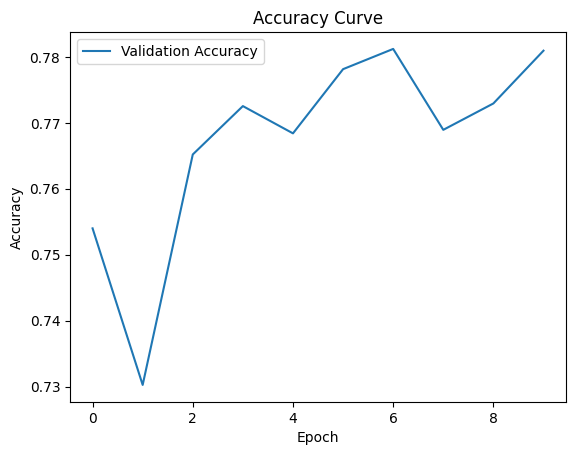

In [14]:
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()
